## Imported Libraries

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from datetime import datetime, timedelta
import os

## YahooFinance Data Fetching

In [8]:
# Determine stock company
tickers = ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'META', 'TSLA', 'WMT', 'AMD']

In [9]:
# End date is today
end_date = datetime.today()
print(end_date)

2026-05-02 17:52:52.142308


In [10]:
# Start date is 5 years ago
start_date = end_date - timedelta(days=10*365.25)
print(start_date)

2016-05-02 05:52:52.142308


In [11]:
# Name this adj_close since 
adj_close = pd.DataFrame()
for ticker in tickers:
    data = yf.download(tickers, start=start_date, end=end_date)
    adj_close[ticker] = data['Close'][ticker]

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed


In [12]:
# Display the data
print(adj_close)

                  NVDA        AAPL        MSFT        AMZN       GOOGL  \
Date                                                                     
2016-05-02    0.881284   21.207628   44.531193   34.192501   35.427696   
2016-05-03    0.870758   21.556410   43.800880   33.566002   35.131634   
2016-05-04    0.850929   21.332199   43.880066   33.544998   35.276939   
2016-05-05    0.856070   21.245609   43.941658   32.954498   35.442570   
2016-05-06    0.864883   21.127121   44.337612   33.697498   35.961777   
...                ...         ...         ...         ...         ...   
2026-04-27  216.610001  267.609985  424.820007  261.119995  350.339996   
2026-04-28  213.169998  270.709991  429.250000  259.700012  349.779999   
2026-04-29  209.250000  270.170013  424.459991  263.040009  349.940002   
2026-04-30  199.570007  271.350006  407.779999  265.059998  384.799988   
2026-05-01  198.449997  280.140015  414.440002  268.260010  385.690002   

                  AVGO        META   

In [13]:
# Download path
output_dir = './Data'
os.makedirs(output_dir, exist_ok=True)

In [14]:
# Export dataframe to excel csv setting
output_file = os.path.join(output_dir, 'stock_data.csv')
adj_close.to_csv(output_file)

## Stock Returns Distribution

In [21]:
# Compute simple daily returns
returns = adj_close.pct_change().dropna()
print(returns.head())

                NVDA      AAPL      MSFT      AMZN     GOOGL      AVGO  \
Date                                                                     
2016-05-03 -0.011944  0.016446 -0.016400 -0.018323 -0.008357 -0.019715   
2016-05-04 -0.022772 -0.010401  0.001808 -0.000626  0.004136 -0.007891   
2016-05-05  0.006042 -0.004059  0.001404 -0.017603  0.004695  0.003590   
2016-05-06  0.010295 -0.005577  0.009011  0.022546  0.014649 -0.004839   
2016-05-09 -0.001415  0.000755 -0.006350  0.008606  0.005447  0.003594   

                META      TSLA       WMT       AMD  
Date                                                
2016-05-03 -0.009615 -0.039206 -0.008729 -0.037433  
2016-05-04  0.005365 -0.042011  0.002836  0.000000  
2016-05-05 -0.002118 -0.049560  0.000298  0.016667  
2016-05-06  0.014260  0.016073  0.015474  0.005464  
2016-05-09 -0.002092 -0.027963  0.010256 -0.008152  


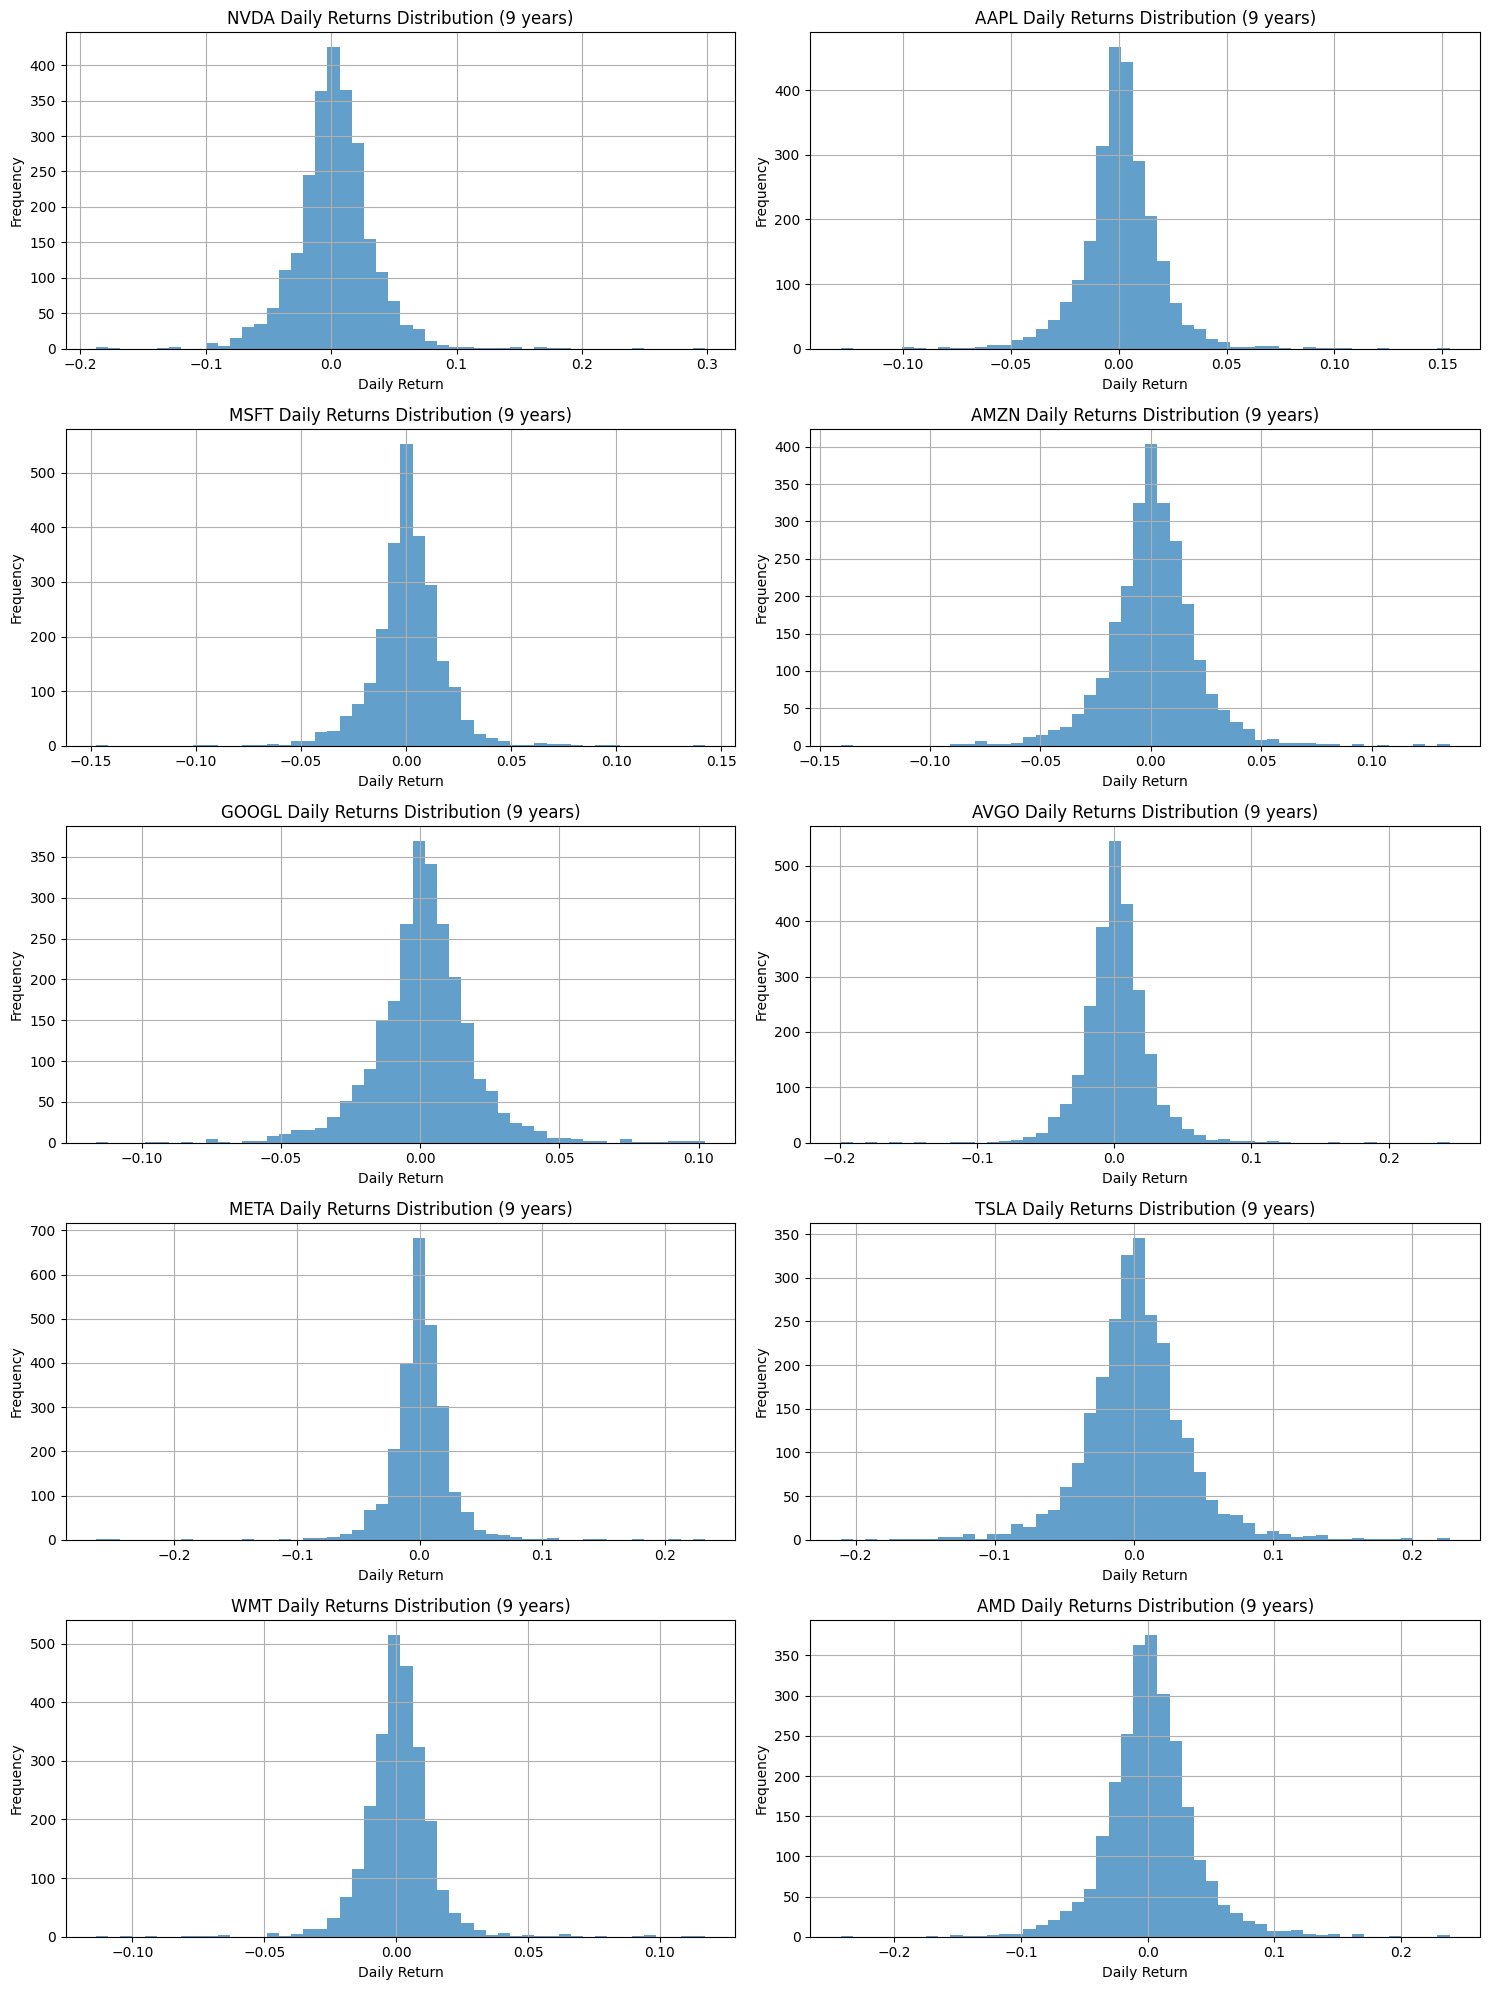

In [22]:
# Visualize the distribution of returns for each stock
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
for i, ticker in enumerate(tickers):
    ax = axes[i // 2, i % 2]
    returns[ticker].hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(f'{ticker} Daily Returns Distribution (9 years)')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Risk Metrics Computation

In [36]:
# VaR: percentile of returns at confidence level
def historical_var(returns, confidence=0.95):
    clean = returns.dropna()
    return -np.percentile(clean, 100 * (1 - confidence))

# CVaR: mean of returns up to VaR threshold
def historical_cvar(returns, confidence=0.95):
    clean = returns.dropna()
    var = historical_var(clean, confidence)
    tail = clean[clean <= -var]
    return -tail.mean() if len(tail) > 0 else np.nan

# Annualize daily metrics (VaR/CVaR) using square root of time scaling
def annualize_metric(metric_daily, trading_days=252):
    return metric_daily * np.sqrt(trading_days)

# Risk Metrics: Compute VaR and CVaR for each stock at specified confidence level, both daily and annualized
def compute_risk_metrics(returns_df, confidence=0.95, trading_days=252):
    results = []
    for ticker in returns_df.columns:
        var_d = historical_var(returns_df[ticker], confidence)
        cvar_d = historical_cvar(returns_df[ticker], confidence)
        var_a = annualize_metric(var_d, trading_days)
        cvar_a = annualize_metric(cvar_d, trading_days)
        results.append({
            'ticker': ticker,
            'confidence': confidence,
            'VaR_daily': var_d,
            'CVaR_daily': cvar_d,
            'VaR_annualized': var_a,
            'CVaR_annualized': cvar_a
        })
    return pd.DataFrame(results).set_index(['ticker', 'confidence'])

In [37]:
# Compute risk metrics for the default confidence level
confidence_level = 0.95
risk_metrics = compute_risk_metrics(returns, confidence=confidence_level)
print(f"Risk metrics at {int(confidence_level * 100)}% confidence")
print(risk_metrics)

Risk metrics at 95% confidence
                   VaR_daily  CVaR_daily  VaR_annualized  CVaR_annualized
ticker confidence                                                        
NVDA   0.95         0.045414    0.067316        0.720929         1.068610
AAPL   0.95         0.027314    0.041340        0.433599         0.656246
MSFT   0.95         0.026330    0.038492        0.417982         0.611042
AMZN   0.95         0.030673    0.046297        0.486915         0.734944
GOOGL  0.95         0.027136    0.041778        0.430767         0.663208
AVGO   0.95         0.034865    0.052985        0.553460         0.841118
META   0.95         0.034635    0.055017        0.549818         0.873373
TSLA   0.95         0.053359    0.081211        0.847048         1.289178
WMT    0.95         0.018540    0.029592        0.294318         0.469754
AMD    0.95         0.051918    0.075275        0.824178         1.194958


## CVaR Portfolio Optimization

### Optimization Problem Formulation

In [41]:
# CVaR portfolio optimization utilities
def portfolio_return(weights, returns_df):
    return returns_df.dot(weights)

# Calculate portfolio metrics (mean return, VaR, CVaR) for given weights and returns dataframe
def portfolio_metrics(weights, returns_df, confidence=0.95, trading_days=252):
    port_r = portfolio_return(weights, returns_df)
    mean_d = port_r.mean()
    var_d = historical_var(port_r, confidence)
    cvar_d = historical_cvar(port_r, confidence)
    var_a = annualize_metric(var_d, trading_days)
    cvar_a = annualize_metric(cvar_d, trading_days)
    return {
        'mean_daily': mean_d,
        'VaR_daily': var_d,
        'CVaR_daily': cvar_d,
        'VaR_annualized': var_a,
        'CVaR_annualized': cvar_a
    }

# Objective function for CVaR optimization (minimize portfolio CVaR)
def cvar_objective(weights, returns_df, confidence=0.95):
    return portfolio_metrics(weights, returns_df, confidence)['CVaR_daily']

In [42]:
n_assets = len(tickers)
init_weights = np.repeat(1 / n_assets, n_assets)
bounds = tuple((0, 1) for _ in range(n_assets))
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)

result_cvar = minimize(
    cvar_objective,
    init_weights,
    args=(returns, confidence_level),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'disp': False}
)

optimal_weights = result_cvar.x
optimal_portfolio = portfolio_metrics(optimal_weights, returns, confidence_level)

# Equal-weighted benchmark
equal_weights = init_weights
benchmark_portfolio = portfolio_metrics(equal_weights, returns, confidence_level)

print('CVaR optimization success:', result_cvar.success)
print('Optimal weights:')
print(pd.Series(optimal_weights, index=tickers).round(4))
print('\nOptimal portfolio metrics:')
for name, value in optimal_portfolio.items():
    print(f'{name}: {value:.6f}')
print('\nEqual-weighted portfolio metrics:')
for name, value in benchmark_portfolio.items():
    print(f'{name}: {value:.6f}')

CVaR optimization success: True
Optimal weights:
NVDA     0.0000
AAPL     0.0000
MSFT     0.1518
AMZN     0.0000
GOOGL    0.1151
AVGO     0.0653
META     0.0000
TSLA     0.0000
WMT      0.6677
AMD      0.0000
dtype: float64

Optimal portfolio metrics:
mean_daily: 0.000978
VaR_daily: 0.016730
CVaR_daily: 0.026141
VaR_annualized: 0.265578
CVaR_annualized: 0.414973

Equal-weighted portfolio metrics:
mean_daily: 0.001498
VaR_daily: 0.027857
CVaR_daily: 0.040227
VaR_annualized: 0.442216
CVaR_annualized: 0.638584


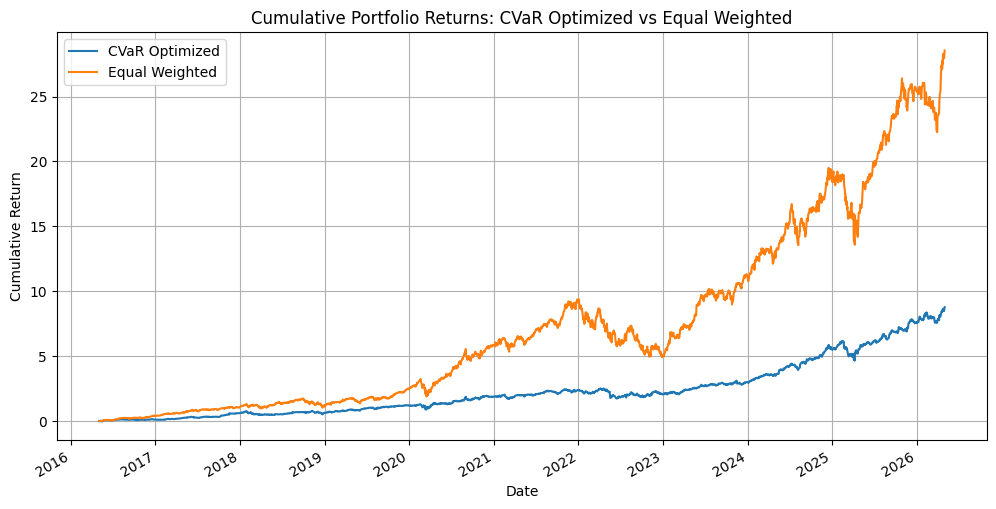

In [43]:
# Plot optimized portfolio vs equal-weighted benchmark
portfolio_returns_opt = portfolio_return(optimal_weights, returns)
portfolio_returns_eq = portfolio_return(equal_weights, returns)

plt.figure(figsize=(12, 6))
((1 + portfolio_returns_opt).cumprod() - 1).plot(label='CVaR Optimized')
((1 + portfolio_returns_eq).cumprod() - 1).plot(label='Equal Weighted')
plt.title('Cumulative Portfolio Returns: CVaR Optimized vs Equal Weighted')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

### (Optional) Mean-CVaR Optimization 

In [44]:
# Mean-CVaR optimization example
risk_aversion = 10.0

def mean_cvar_objective(weights, returns_df, confidence=0.95, risk_aversion=10.0):
    metrics = portfolio_metrics(weights, returns_df, confidence)
    return -metrics['mean_daily'] + risk_aversion * metrics['CVaR_daily']

result_mean_cvar = minimize(
    mean_cvar_objective,
    init_weights,
    args=(returns, confidence_level, risk_aversion),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'disp': False}
)

mean_cvar_weights = result_mean_cvar.x
mean_cvar_portfolio = portfolio_metrics(mean_cvar_weights, returns, confidence_level)

print('Mean-CVaR optimization success:', result_mean_cvar.success)
print('Mean-CVaR weights:')
print(pd.Series(mean_cvar_weights, index=tickers).round(4))
print('\nMean-CVaR portfolio metrics:')
for name, value in mean_cvar_portfolio.items():
    print(f'{name}: {value:.6f}')

Mean-CVaR optimization success: True
Mean-CVaR weights:
NVDA     0.0000
AAPL     0.0000
MSFT     0.1566
AMZN     0.0000
GOOGL    0.1107
AVGO     0.0656
META     0.0000
TSLA     0.0000
WMT      0.6671
AMD      0.0000
dtype: float64

Mean-CVaR portfolio metrics:
mean_daily: 0.000978
VaR_daily: 0.016765
CVaR_daily: 0.026141
VaR_annualized: 0.266141
CVaR_annualized: 0.414972


## Backtesting & Benchmarking

### CVaR-Portfolio Returns 

In [ ]:
# Compute the optimal returns 

### Portfolio Variants Comparison 

In [ ]:
# Objective: Equal-weighted, CVaR, Mean-CVaR,...


### (Optional) Model Performance Metrics 

#### Sharpe Ratio

In [25]:
#

#### Confidence Level Sensitivity 

In [26]:
#

#### Monte-Carlo Simulation 

In [ ]:
#